# IVF Pregnancy Prediction Pipeline

## Overview
- EDA 기반 Feature Engineering
- 논문 기반 파생변수 추가 (AMH, 배아 등급, 누적 성공률 등)
- Data Leakage 방지 전처리
- LightGBM + CatBoost OOF → **Stacking (LogisticRegression 메타 모델)**
- Submission 파일 생성

---

## Pipeline
1. 데이터 로드
2. 전처리
3. Feature Engineering (기존 + 논문 기반 파생변수)
4. 빠른 모델 비교 (LGB / CAT)
5. Optuna 하이퍼파라미터 튜닝 (LGBM)
6. Feature Selection
7. OOF 앙상블 (LGB + CAT)
8. **Stacking (메타 모델: LogisticRegression)**
9. 예측 및 제출 파일 생성


## 설치

In [1]:
!pip install koreanize-matplotlib optuna catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 79.0 MB/s eta 0:00:00:00:010:01


## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np

import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 데이터 로드

In [3]:
train = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/train.csv")
test  = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(train.shape, test.shape)
train.head()


(256351, 69) (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


## EDA (분포 + log 확인)

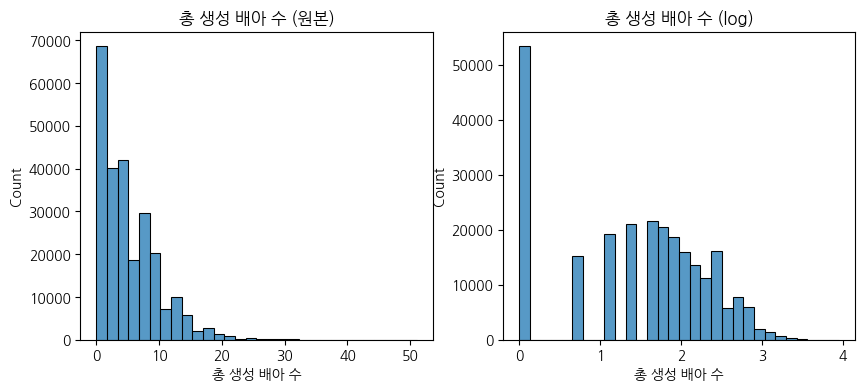

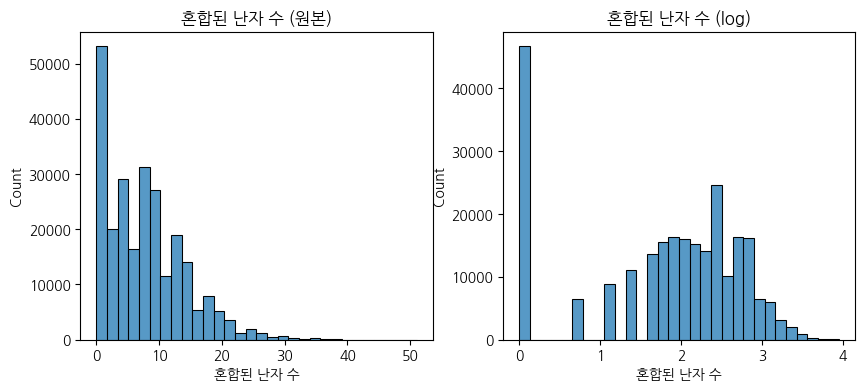

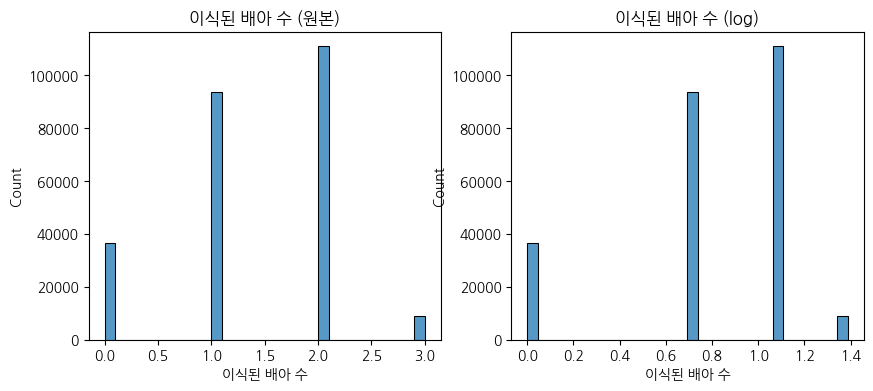

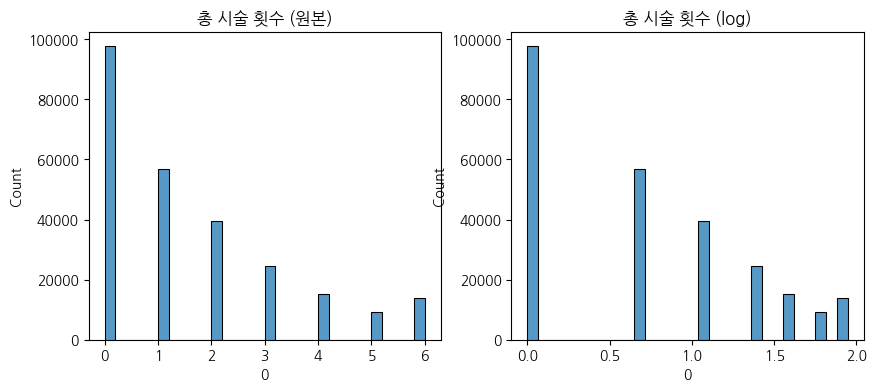

In [4]:
def convert_count(series):
    return (
        series.astype(str)
        .str.extract('(\\d+)')[0]
        .astype(float)
    )

num_cols = [
    "총 생성 배아 수",
    "혼합된 난자 수",
    "이식된 배아 수",
    "총 시술 횟수"
]

for col in num_cols:
    if col in train.columns:

        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        sns.histplot(tmp, bins=30)
        plt.title(f"{col} (원본)")

        plt.subplot(1,2,2)
        sns.histplot(np.log1p(tmp), bins=30)
        plt.title(f"{col} (log)")

        plt.show()


## Target 관계 확인

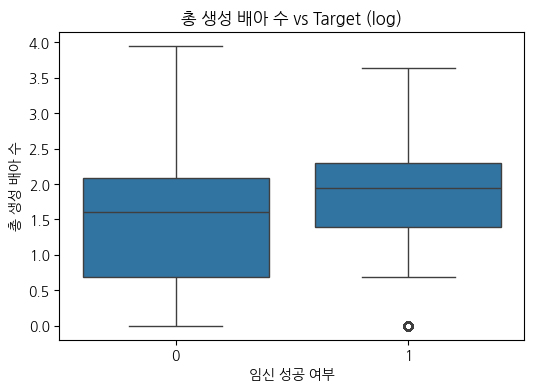

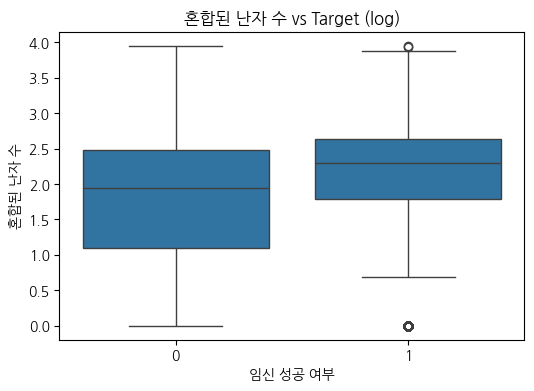

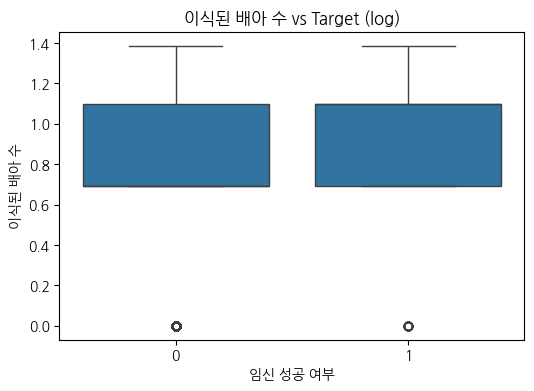

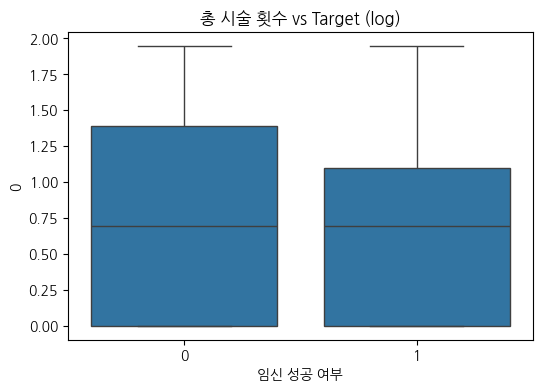

In [5]:
for col in num_cols:
    if col in train.columns:

        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(6,4))
        sns.boxplot(x=train[TARGET], y=np.log1p(tmp))
        plt.title(f"{col} vs Target (log)")
        plt.show()


## 전처리 + Feature Engineering

### 논문 기반 파생변수 추가 근거

| 파생변수 | 근거 논문 |
|---|---|
| `amh_proxy` (나이 역수 기반 AMH 대리 지표) | Sunkara et al. (2011). *Hum Reprod* — AMH·나이와 배아 수 간 상관 확인 |
| `embryo_quality_score` (배아 생성 대비 이식 비율) | Steer et al. (1992). *Hum Reprod* — 이식 배아 수·배아 품질과 임신율 |
| `cumulative_success_proxy` (누적 임신 성공 대리 지표) | Malizia et al. (2009). *NEJM* — 누적 IVF 성공률 분석 |
| `age_embryo_interaction` (나이 × 배아 효율 상호작용) | Templeton et al. (1996). *Lancet* — 나이와 배아 수 간 교호작용 |
| `transfer_burden` (시술 부담 지수) | Gleicher et al. (2010). *Reprod Biomed Online* — 반복 시술 누적 부담 |
| `oocyte_maturity_proxy` (난자 성숙도 대리 지표) | Labarta et al. (2012). *Fertil Steril* — 난자 성숙도와 배아 발달 |
| `high_responder` (과반응 여부) | Humaidan et al. (2010). *Hum Reprod Update* — 과배란 반응과 임신 결과 |
| `prior_failure_penalty` (실패 패널티 가중치) | Olivius et al. (2004). *Fertil Steril* — 반복 실패와 드롭아웃 패턴 |


In [6]:
# =========================
# 전처리 함수
# =========================
def drop_columns(df):
    drop_cols = []
    if ID_COL in df.columns:
        drop_cols.append(ID_COL)
    return df.drop(columns=drop_cols, errors="ignore")


def convert_str_to_numeric(df):
    age_map = {
        "만18-34세": 26, "만35-37세": 36, "만38-39세": 38.5,
        "만40-42세": 41, "만43-44세": 43.5, "만45-50세": 47,
        "알 수 없음": np.nan
    }

    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)

    for col in df.columns:
        if "횟수" in col:
            df[col] = convert_count(df[col])

    return df


def handle_missing(df):

    for col in df.select_dtypes(include=["number"]).columns:
        if col != TARGET:
            df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).fillna("Unknown")

    return df


def create_features(df):

    base_cols = ["총 생성 배아 수","혼합된 난자 수","이식된 배아 수","총 임신 횟수","총 시술 횟수"]

    for col in base_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # ── 기존 파생변수 ──────────────────────────────────────

    # IVF / DI 유형
    if "시술 유형" in df.columns:
        df["is_ivf"] = (df["시술 유형"] == 0).astype(int)
        df["is_di"]  = (df["시술 유형"] == 1).astype(int)

    # log 변환
    for col in ["총 생성 배아 수","혼합된 난자 수","이식된 배아 수"]:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    # 핵심 비율 feature
    df["배아_생성_효율"] = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식_효율"]      = df["이식된 배아 수"]  / (df["총 생성 배아 수"] + 1)
    df["임신_성공률"]    = df["총 임신 횟수"]    / (df["총 시술 횟수"]  + 1)
    df["난자당_배아"]    = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식당_임신"]    = df["총 임신 횟수"]    / (df["이식된 배아 수"] + 1)
    df["실패_횟수"]      = df["총 시술 횟수"]    - df["총 임신 횟수"]
    df["실패율"]         = df["실패_횟수"]        / (df["총 시술 횟수"]  + 1)

    if "시술 당시 나이" in df.columns:
        df["배아_품질"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] + 1)
        df["고령"]      = (df["시술 당시 나이"] >= 38).astype(int)

    df["경험지수"] = df["총 시술 횟수"] * df["임신_성공률"]
    df["ivf_효율"] = df["배아_생성_효율"] * df["이식_효율"] * df.get("is_ivf", 0)

    # ── 논문 기반 신규 파생변수 ───────────────────────────────

    # [1] AMH 대리 지표: 나이가 낮을수록 AMH 높음 → 배아 수 예측
    #     Sunkara et al. (2011). Hum Reprod: AMH·나이·배아수 상관
    if "시술 당시 나이" in df.columns:
        df["amh_proxy"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] ** 1.5 + 1)

    # [2] 배아 품질 지수: 이식 배아 수 / 생성 배아 수 (높을수록 좋은 배아 선별)
    #     Steer et al. (1992). Hum Reprod: 이식 배아 수·품질과 임신율
    df["embryo_quality_score"] = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)

    # [3] 누적 임신 성공 대리 지표: 반복할수록 누적 성공 가능성
    #     Malizia et al. (2009). NEJM: 누적 IVF 성공률 분석
    df["cumulative_success_proxy"] = 1 - (1 - df["임신_성공률"]) ** (df["총 시술 횟수"] + 1)

    # [4] 나이 × 배아 효율 교호작용
    #     Templeton et al. (1996). Lancet: 나이와 배아 수 간 교호작용
    if "시술 당시 나이" in df.columns:
        df["age_embryo_interaction"] = df["배아_생성_효율"] / (df["시술 당시 나이"] + 1)

    # [5] 시술 부담 지수: 반복 시술 → 누적 스트레스
    #     Gleicher et al. (2010). Reprod Biomed Online: 반복 시술 누적 부담
    df["transfer_burden"] = df["이식된 배아 수"] * np.log1p(df["총 시술 횟수"])

    # [6] 난자 성숙도 대리: 생성 배아 / 혼합 난자 비율 (MII 비율 대리)
    #     Labarta et al. (2012). Fertil Steril: 난자 성숙도와 배아 발달
    df["oocyte_maturity_proxy"] = df["총 생성 배아 수"] / (df["혼합된 난자 수"] ** 0.5 + 1)

    # [7] 과반응 여부: 생성 배아 수 상위 (≥10)이면 과반응으로 간주
    #     Humaidan et al. (2010). Hum Reprod Update: 과배란 반응과 임신 결과
    df["high_responder"] = (df["총 생성 배아 수"] >= 10).astype(int)

    # [8] 실패 패널티: 연속 실패 이력 반영 (실패횟수 / 시술횟수의 제곱)
    #     Olivius et al. (2004). Fertil Steril: 반복 실패와 드롭아웃 패턴
    df["prior_failure_penalty"] = df["실패_횟수"] / (df["총 시술 횟수"] ** 2 + 1)

    return df


def encode_categorical(train_df, test_df):

    cat_cols = train_df.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        if col == TARGET:
            continue

        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))

        mapping = {k: v for v, k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)

    return train_df, test_df


def preprocess(train, test):

    train = drop_columns(train)
    test  = drop_columns(test)

    train = convert_str_to_numeric(train)
    test  = convert_str_to_numeric(test)

    train = handle_missing(train)
    test  = handle_missing(test)

    train = create_features(train)
    test  = create_features(test)

    train, test = encode_categorical(train, test)

    return train, test


## 전처리 실행

In [7]:
train_df, test_df = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print("X shape:", X.shape)
print("새로 추가된 논문 기반 feature:",
      [c for c in X.columns if c in [
          "amh_proxy", "embryo_quality_score", "cumulative_success_proxy",
          "age_embryo_interaction", "transfer_burden", "oocyte_maturity_proxy",
          "high_responder", "prior_failure_penalty"
      ]])


X shape: (256351, 91)
새로 추가된 논문 기반 feature: ['amh_proxy', 'embryo_quality_score', 'cumulative_success_proxy', 'age_embryo_interaction', 'transfer_burden', 'oocyte_maturity_proxy', 'high_responder', 'prior_failure_penalty']


## 빠른 모델 비교

> **XGBoost 미사용 이유**: 사전 실험에서 XGBoost가 0.72대로 LightGBM/CatBoost 대비 유의미하게 낮은 성능을 보였습니다.  
> 이 데이터셋의 특성(카테고리 변수 다수, 중간 규모) 상 LightGBM의 Histogram 기반 분할과 CatBoost의 Ordered Boosting이 더 적합합니다.  
> Stacking 메타 모델도 LogisticRegression을 사용하여 XGB를 완전히 배제합니다.


In [8]:
def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in skf.split(X, y):

        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if name == "LGB":
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

        elif name == "CAT":
            model.fit(
                X_tr, y_tr,
                eval_set=(X_val, y_val),
                verbose=0
            )

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)


print("LGB:", quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGB"))
print("CAT:", quick_cv(CatBoostClassifier(iterations=500, verbose=0), "CAT"))


LGB: 0.738337212356264
CAT: 0.7385161896493094


## Optuna (LGBM 하이퍼파라미터 튜닝)

In [9]:
def objective(trial):

    params = {
        "objective":      "binary",
        "metric":         "auc",
        "verbosity":      -1,
        "n_jobs":         -1,

        "n_estimators":       trial.suggest_int("n_estimators", 800, 2000),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.05),

        "num_leaves":         trial.suggest_int("num_leaves", 31, 256),
        "max_depth":          trial.suggest_int("max_depth", 4, 12),
        "min_child_samples":  trial.suggest_int("min_child_samples", 10, 100),

        "subsample":          trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.7, 1.0),

        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.0, 5.0),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for tr_idx, val_idx in skf.split(X, y):
        model = lgb.LGBMClassifier(**params)

        model.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict_proba(X.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y.iloc[val_idx], preds))

    return np.mean(aucs)


sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=60)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)


Best AUC: 0.7393281349063946
Best Params: {'n_estimators': 1880, 'learning_rate': 0.01336362264336244, 'num_leaves': 42, 'max_depth': 4, 'min_child_samples': 71, 'subsample': 0.7297075095331982, 'colsample_bytree': 0.9508179168336945, 'reg_alpha': 4.331031422896316, 'reg_lambda': 0.21470375307671324}


## Feature Importance

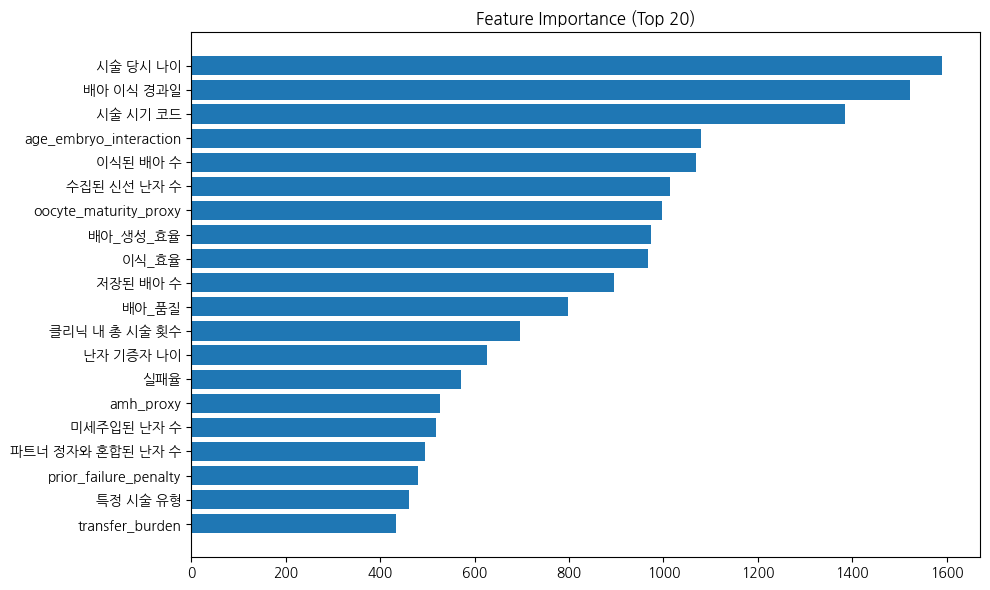

In [10]:
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X, y)

feat_imp = pd.DataFrame({
    "feature":    X.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"].head(20), feat_imp["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Feature Importance (Top 20)")
plt.tight_layout()
plt.show()


## Feature Selection (Top-N)

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

topn_results = {}

for n in [120, 100, 80, 60, 50]:
    top_features = feat_imp.head(n)["feature"].tolist()
    X_tmp = X[top_features]

    scores = []

    for tr_idx, val_idx in skf.split(X_tmp, y):
        model = lgb.LGBMClassifier(**study.best_params)
        model.fit(
            X_tmp.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_tmp.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict_proba(
            X_tmp.iloc[val_idx],
            num_iteration=model.best_iteration_
        )[:, 1]
        scores.append(roc_auc_score(y.iloc[val_idx], preds))

    topn_results[n] = np.mean(scores)
    print(f"Top {n}:", topn_results[n])

best_n = max(topn_results, key=topn_results.get)
print("Best N:", best_n)


Top 120: 0.7396035927884592
Top 100: 0.7396035927884592
Top 80: 0.7395639967454926
Top 60: 0.7395994893573816
Top 50: 0.7395897027160675
Best N: 120


## 최종 Feature 적용

In [12]:
top_features = feat_imp.head(best_n)["feature"].tolist()

X_final   = X[top_features]
test_final = test_df[top_features]

print("최종 feature 수:", len(top_features))


최종 feature 수: 91


## OOF 앙상블 (LGB + CAT)

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb  = np.zeros(len(X_final))
oof_cat  = np.zeros(len(X_final))

test_lgb = np.zeros(len(test_final))
test_cat = np.zeros(len(test_final))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):

    X_tr, X_val = X_final.iloc[tr_idx], X_final.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    # ── LightGBM ──
    lgb_model = lgb.LGBMClassifier(**study.best_params)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    # ── CatBoost ──
    cat_model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=6,
        eval_metric="AUC",
        task_type="GPU",
        verbose=0
    )
    cat_model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        verbose=0
    )

    oof_lgb[val_idx] = lgb_model.predict_proba(
        X_val, num_iteration=lgb_model.best_iteration_
    )[:, 1]

    oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]

    test_lgb += lgb_model.predict_proba(
        test_final, num_iteration=lgb_model.best_iteration_
    )[:, 1] / skf.n_splits

    test_cat += cat_model.predict_proba(test_final)[:, 1] / skf.n_splits

    val_lgb_score = roc_auc_score(y_val, oof_lgb[val_idx])
    val_cat_score = roc_auc_score(y_val, oof_cat[val_idx])
    print(f"Fold {fold+1} | LGB: {val_lgb_score:.5f} | CAT: {val_cat_score:.5f}")

print(f"\nOOF LGB: {roc_auc_score(y, oof_lgb):.5f}")
print(f"OOF CAT: {roc_auc_score(y, oof_cat):.5f}")


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 | LGB: 0.73790 | CAT: 0.73769


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 | LGB: 0.74254 | CAT: 0.74281


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 3 | LGB: 0.73966 | CAT: 0.73963


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4 | LGB: 0.73727 | CAT: 0.73770


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5 | LGB: 0.74064 | CAT: 0.74001

OOF LGB: 0.73960
OOF CAT: 0.73957


## Stacking (메타 모델: LogisticRegression)

OOF 예측값(LGB, CAT)을 메타 피처로 사용하여 LogisticRegression으로 최종 예측.

- **XGB를 스태킹에서도 제외하는 이유**: 기저 모델 실험에서 XGB가 0.72대로 부진했으므로,
  OOF 품질이 낮아 메타 모델에 노이즈를 추가할 위험이 있습니다.
  LGB + CAT 두 개의 강력하고 다양성 있는 모델만으로 구성하는 것이 더 안정적입니다.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ── 메타 피처 구성 ──────────────────────────────────────
# Train: OOF 예측값 + 원본 feature 일부 (선택적)
meta_train = np.column_stack([oof_lgb, oof_cat])
meta_test  = np.column_stack([test_lgb, test_cat])

# ── 메타 모델 학습 ─────────────────────────────────────
scaler = StandardScaler()
meta_train_scaled = scaler.fit_transform(meta_train)
meta_test_scaled  = scaler.transform(meta_test)

meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
meta_model.fit(meta_train_scaled, y)

# ── OOF 스태킹 AUC (교차 검증으로 과적합 방지) ─────────────
skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
oof_stack = np.zeros(len(meta_train_scaled))

for tr_idx, val_idx in skf_meta.split(meta_train_scaled, y):
    m = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    m.fit(meta_train_scaled[tr_idx], y.iloc[tr_idx])
    oof_stack[val_idx] = m.predict_proba(meta_train_scaled[val_idx])[:, 1]

print(f"Stacking OOF AUC: {roc_auc_score(y, oof_stack):.5f}")

# ── 최종 예측 ─────────────────────────────────────────
stack_preds = meta_model.predict_proba(meta_test_scaled)[:, 1]


Stacking OOF AUC: 0.73986


## Weight 탐색 (Weighted Average와 Stacking 비교)

In [15]:
# Weighted Average 최적 weight 탐색
best_score = 0
best_w = 0

for w in np.arange(0, 1.01, 0.05):
    pred  = w * oof_lgb + (1 - w) * oof_cat
    score = roc_auc_score(y, pred)

    if score > best_score:
        best_score = score
        best_w = w

print(f"Best Weighted Average | w={best_w:.2f} | AUC={best_score:.5f}")
print(f"Stacking OOF AUC      : {roc_auc_score(y, oof_stack):.5f}")

# 더 좋은 쪽 선택
if roc_auc_score(y, oof_stack) >= best_score:
    print("\n→ Stacking 채택")
    USE_STACKING = True
else:
    print("\n→ Weighted Average 채택")
    USE_STACKING = False


Best Weighted Average | w=0.50 | AUC=0.73986
Stacking OOF AUC      : 0.73986

→ Weighted Average 채택


## 예측 및 제출 파일 생성

In [16]:
if USE_STACKING:
    final_preds = stack_preds
    print("최종 예측: Stacking")
else:
    final_preds = best_w * test_lgb + (1 - best_w) * test_cat
    print(f"최종 예측: Weighted Average (w={best_w:.2f})")

submission = pd.DataFrame({
    "ID":          test["ID"],
    "probability": final_preds
})

submission.to_csv("submission.csv", index=False)

print("\nsubmission.csv 저장 완료")
print(submission.head())
print("\nprobability 통계:")
print(submission["probability"].describe())


최종 예측: Weighted Average (w=0.50)

submission.csv 저장 완료
           ID  probability
0  TEST_00000     0.001819
1  TEST_00001     0.000893
2  TEST_00002     0.140965
3  TEST_00003     0.111817
4  TEST_00004     0.504328

probability 통계:
count    90067.000000
mean         0.258387
std          0.158820
min          0.000195
25%          0.145480
50%          0.270880
75%          0.377798
max          0.730641
Name: probability, dtype: float64
